# OpenArt — Exploratory Data Analysis

Corpus snapshot: `data/raw/opportunities.csv` 

In [216]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.figsize"] = (9, 5)
sns.set_theme(style="whitegrid")

REPO_ROOT = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(REPO_ROOT, "dataset", "opportunities.csv")

In [217]:
df = pd.read_csv(DATA_PATH)
df.shape

(479, 37)

## Data cleaning summary

This corpus was cleaned upstream by an automated pipeline (`src/processing/`), not here — see `workflow.MD` for the full design rationale and `ANNOTATION_GUIDELINES.md` for annotation-specific caveats (a small number of excluded rows). The cells below don't redo that work; they just show what it did, since the raw and cleaned columns both survive side by side in `dataset/opportunities.csv` for exactly this purpose.

Pipeline stages: deadline parsing (locale-specific bugs, PDF-extraction artifacts, date-range year inheritance) → content-based deduplication → categorical canonicalization (`discipline`/`opportunity_type`/`career_stage`/`country`, translated then mapped onto a fixed vocabulary) → structured extraction (`funding`/`application_fee` → category + amount + currency + period) → placeholder-leak cleanup (a few rows had a literal `"null"`/`"[not present in provided text]"` string instead of an actual null).

In [218]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 37 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          479 non-null    str    
 1   source                      479 non-null    str    
 2   source_url                  479 non-null    str    
 3   application_url             315 non-null    str    
 4   organisation                479 non-null    str    
 5   description                 479 non-null    str    
 6   discipline                  474 non-null    str    
 7   opportunity_type            479 non-null    str    
 8   country                     437 non-null    str    
 9   city                        208 non-null    str    
 10  funding                     389 non-null    str    
 11  application_fee             35 non-null     str    
 12  career_stage                117 non-null    str    
 13  description_en              479 non-null    st

In [219]:
df.isna().sum()

id                              0
source                          0
source_url                      0
application_url               164
organisation                    0
description                     0
discipline                      5
opportunity_type                0
country                        42
city                          271
funding                        90
application_fee               444
career_stage                  362
description_en                  0
discipline_en                   5
opportunity_type_en             0
career_stage_en               362
country_en                     42
city_en                       271
discipline_canonical            0
opportunity_type_canonical      0
career_stage_canonical          0
country_canonical               0
funding_components              0
funding_extracted_at           90
application_fee_has_fee       444
application_fee_amount_min    464
application_fee_amount_max    464
application_fee_currency      464
language      

In [220]:
df.head()

,id,source,source_url,application_url,organisation,description,discipline,opportunity_type,country,city,funding,application_fee,career_stage,description_en,discipline_en,opportunity_type_en,career_stage_en,country_en,city_en,discipline_canonical,opportunity_type_canonical,career_stage_canonical,country_canonical,funding_components,funding_extracted_at,application_fee_has_fee,application_fee_amount_min,application_fee_amount_max,application_fee_currency,language,title,requirements_text,title_en,requirements_text_en,deadline_raw,deadline_date,processed_at
0,akademie_schloss_solitude_a8aba5b303e4,akademie_schloss_solitude,https://www.akademie-solitude.de/en/fellowship/solitude-fellowship/,https://application.akademie-solitude.de/fellowship-information/solitude-fel...,Akademie Schloss Solitude,The Akademie Schloss Solitude in Stuttgart awards between 50 and 60 residenc...,all disciplines,residency,Germany,Stuttgart,"A monthly fellowship of €1,300 to cover living expenses",NaN,"artists, scholars, and cultural practitioners from around the world who have...",The Akademie Schloss Solitude in Stuttgart awards between 50 and 60 residenc...,all disciplines,residency,"artists, scholars, and cultural practitioners from around the world who have...",Germany,Stuttgart,['Multidisciplinary'],['Residency'],"['Established/Professional', 'Mid-Career']",['Germany'],"[{'category': 'Grant/Stipend', 'amount_min': 1300.0, 'amount_max': 1300.0, '...",2026-09-24 08:56:51.874575+00:00,NaN,NaN,NaN,NaN,en,Solitude Fellowship,"The fellowship is aimed at artists, scholars, and cultural practitioners fro...",Solitude Fellowship,"The fellowship is aimed at artists, scholars, and cultural practitioners fro...",NaN,NaN,2026-09-23 12:36:39.258102+00:00
1,bmwkms_austria_57c6352e8fbc,bmwkms_austria,https://www.bmwkms.gv.at/themen/kunst-und-kultur/service-kunst-und-kultur/ku...,https://www.bmkoes.gv.at/kunst-und-kultur/service-kunst-und-kultur/foerderun...,"Bundesministerium für Wohnen, Kunst, Kultur, Medien und Sport",Die Kunst- und Kulturszene lebt vom ständigen Austausch auf internationaler ...,"bildende Kunst, Fotografie und Medienkunst",Stipendium,Österreich,NaN,"Mit der Vergabe der Ateliers, die einzelnen Künstler:innen abhängig vom Atel...",NaN,NaN,The art and cultural scene thrives on constant exchange at the international...,"visual arts, photography and media art",stipend,NaN,Austria,NaN,"['Visual Arts', 'Photography', 'Digital/New Media Arts']",['Grant/Funding'],[],['Austria'],"[{'category': 'Grant/Stipend', 'amount_min': 2000.0, 'amount_max': 2000.0, '...",2026-09-24 08:56:51.874736+00:00,NaN,NaN,NaN,NaN,de,Ausschreibung Auslandsstipendien für Künstler:innen der Bereiche bildende Ku...,"Antragsberechtigt sind Künstler:innen , die die österreichische Staatsbürger...",Call for applications: foreign residencies for artists in the fields of visu...,Artists who hold Austrian citizenship or have their permanent residence in A...,30. September 2026,2026-09-30,2026-09-23 12:36:41.344018+00:00
2,bmwkms_austria_36f95e7e131b,bmwkms_austria,https://www.bmwkms.gv.at/themen/kunst-und-kultur/service-kunst-und-kultur/ku...,https://transparenzportal.gv.at/tdb/tp/menu_ml_meineLeistungen,"BMWKMS (Bundesministerium für Kunst, Kultur, öffentlichen Dienst und Sport)",Die Staatsstipendien stellen eine Anerkennung bisheriger hervorragender küns...,"Bildende Kunst, Fotografie und Medienkunst",Stipendium,Österreich,NaN,"Dotierung mit je EUR 18.000,00",NaN,NaN,The state grants constitute recognition of previous outstanding artistic ach...,"visual arts, photography and media art",stipend,NaN,Austria,NaN,"['Visual Arts', 'Photography', 'Digital/New Media Arts']",['Grant/Funding'],[],['Austria'],"[{'category': 'Grant/Stipend', 'amount_min': 18000.0, 'amount_max': 18000.0,...",2026-09-24 08:56:51.874778+00:00,NaN,NaN,NaN,NaN,de,"Staatsstipendien 2027: Bildende Kunst, Fotografie und Medienkunst","Eingeladen sind Künstler:innen (ausschließlich Einzelpersonen), die die öste...","State S

In [221]:
discipline_counts = df["discipline"].fillna("(not stated)").value_counts()
print(discipline_counts)
print(f"\n{df['discipline'].isna().sum()} entries ({df['discipline'].isna().mean():.1%}) have no stated discipline")

discipline
visual arts                      15
Visuelle Kunst                   11
literatúra                        9
performing arts                   6
artists                           6
                                 ..
arte y la educación               1
any discipline                    1
artes visuales                    1
theatre                           1
visual art, crafts and design     1
Name: count, Length: 348, dtype: int64

5 entries (1.0%) have no stated discipline


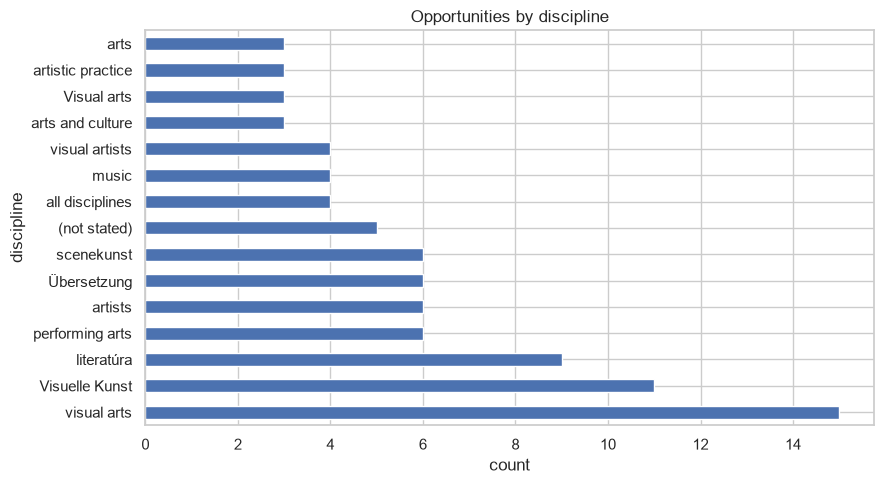

In [222]:
discipline_counts.head(15).plot(kind="barh", title="Opportunities by discipline")
plt.xlabel("count")
plt.tight_layout()
plt.show()

country
Belgium                    51
(not stated)               42
Norge                      33
Slovensko                  32
France                     22
                           ..
Austria                     1
NRW                         1
Turkey                      1
Israel                      1
UK and around the world     1
Name: count, Length: 104, dtype: int64

103 distinct countries represented


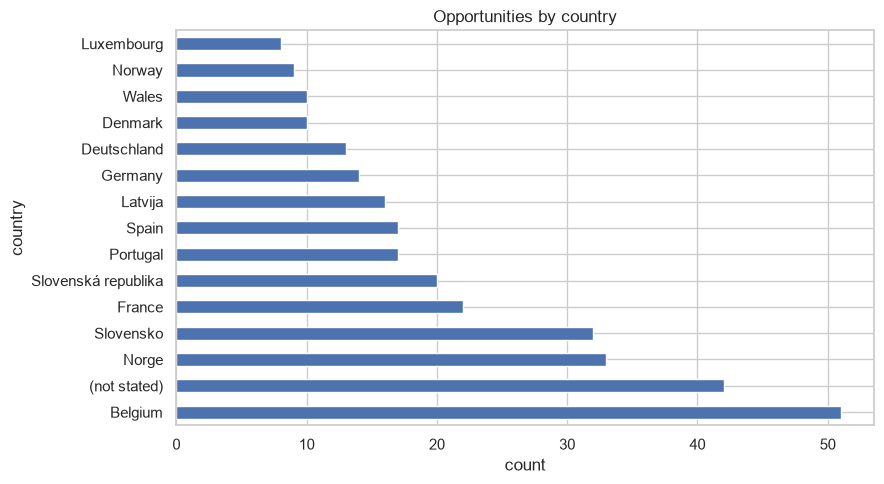

In [223]:
country_counts = df["country"].fillna("(not stated)").value_counts()
print(country_counts)
print(f"\n{df['country'].nunique()} distinct countries represented")
 
country_counts.head(15).plot(kind="barh", title="Opportunities by country")
plt.xlabel("count")
plt.tight_layout()
plt.show()

In [224]:
print("By source:")
print(df["source"].value_counts())

By source:
source
kunsten_be_flanders                    119
fpu_slovakia                            59
kulturdirektoratet_norway               41
mondriaan_fund                          18
vkkf_konkursu_grafiks                   18
dgartes_portugal                        15
kunststiftung_nrw                       13
matadero_madrid                         12
deutscher_uebersetzerfonds              12
arts_council_wales                      11
villa_arson                             10
cite_internationale_des_arts             9
kunst_dk_denmark                         9
creative_ireland                         9
nordic_culture_point                     8
ekkomed_greece                           8
european_cultural_foundation             7
focuna_luxembourg                        7
institut_francais_programs               7
min_kulture_croatia                      7
gasworks_london                          6
national_culture_fund_bulgaria           6
bmwkms_austria                      

Funded (funding field populated): 389 (81.2%)
Charges an application fee: 35 (7.3%)


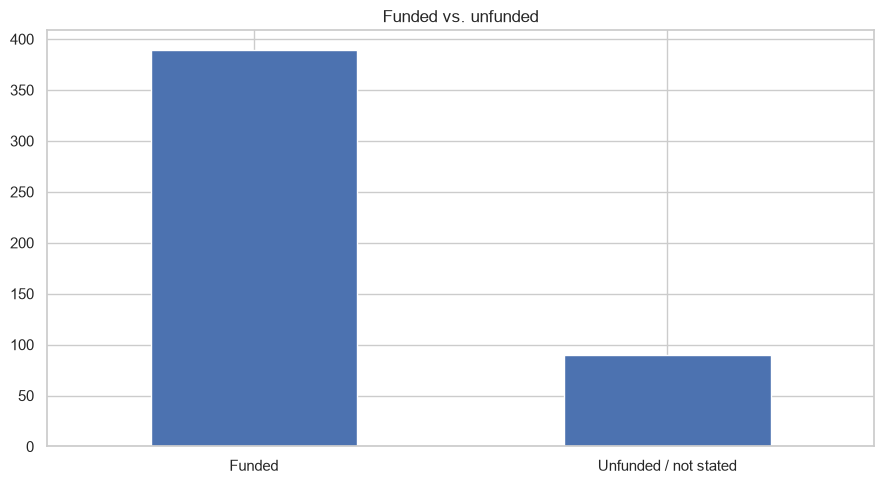

In [225]:
has_funding = df["funding"].notna() & (df["funding"].astype(str).str.strip() != "")
print(f"Funded (funding field populated): {has_funding.sum()} ({has_funding.mean():.1%})")

has_fee = df["application_fee"].notna() & (df["application_fee"].astype(str).str.strip() != "")
print(f"Charges an application fee: {has_fee.sum()} ({has_fee.mean():.1%})")

pd.Series({"Funded": has_funding.sum(), "Unfunded / not stated": (~has_funding).sum()}).plot(
    kind="bar", title="Funded vs. unfunded", rot=0
)
plt.tight_layout()
plt.show()

  RESIDENCE/NATIONALITY     present in  137 entries (28.6%)
  AGE                       present in  185 entries (38.6%)
  DISCIPLINE                present in   81 entries (16.9%)
  CAREER_STAGE              present in   96 entries (20.0%)
  EDUCATION                 present in   51 entries (10.6%)

  Entries with NO matched eligibility keyword at all: 141 (29.4%)
  -> this is your rough preview of how big the NONE class will be


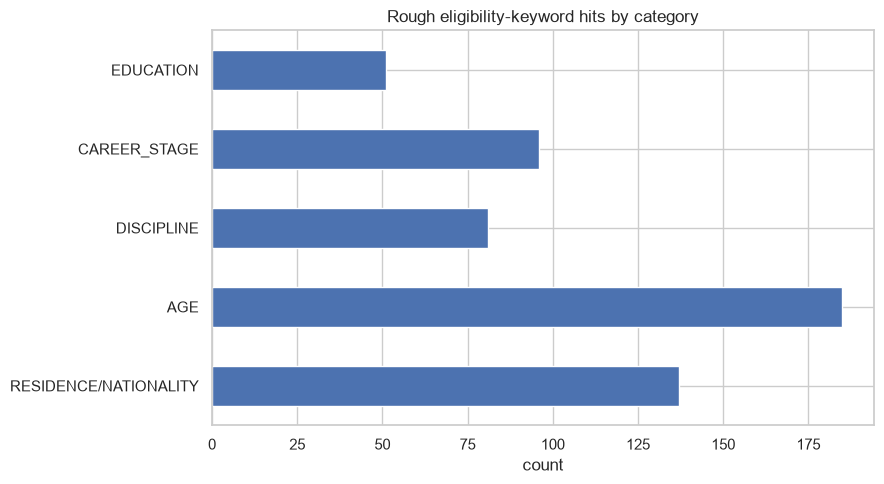

In [226]:
ELIGIBILITY_KEYWORDS = {
    "RESIDENCE/NATIONALITY": ["resident", "citizen", "nationality", "based in", "resid"],
    "AGE": ["age", "years old", "born after", "aged"],
    "DISCIPLINE": ["discipline", "medium", "practice in", "visual art", "sculpture", "painting"],
    "CAREER_STAGE": ["emerging", "early-career", "established", "professional artist"],
    "EDUCATION": ["degree", "enrolled", "student", "graduate"],
}
 
text_col = df["requirements_text_en"] if "requirements_text_en" in df.columns else df["requirements_text"]
text_lower = text_col.fillna("").str.lower()
 
keyword_hits = {}
for label, keywords in ELIGIBILITY_KEYWORDS.items():
    mask = text_lower.str.contains("|".join(keywords), regex=True)
    keyword_hits[label] = mask.sum()
    print(f"  {label:25s} present in {mask.sum():4d} entries ({mask.mean():.1%})")
 
any_keyword = text_lower.str.contains("|".join(sum(ELIGIBILITY_KEYWORDS.values(), [])), regex=True)
none_count = (~any_keyword).sum()
print(f"\n  Entries with NO matched eligibility keyword at all: {none_count} ({(~any_keyword).mean():.1%})")
print("  -> this is your rough preview of how big the NONE class will be")
 
pd.Series(keyword_hits).plot(kind="barh", title="Rough eligibility-keyword hits by category")
plt.xlabel("count")
plt.tight_layout()
plt.show()

count    479.000000
mean     105.789144
std      112.416345
min        2.000000
25%       31.000000
50%       69.000000
75%      128.000000
max      634.000000
Name: requirements_text_en, dtype: float64


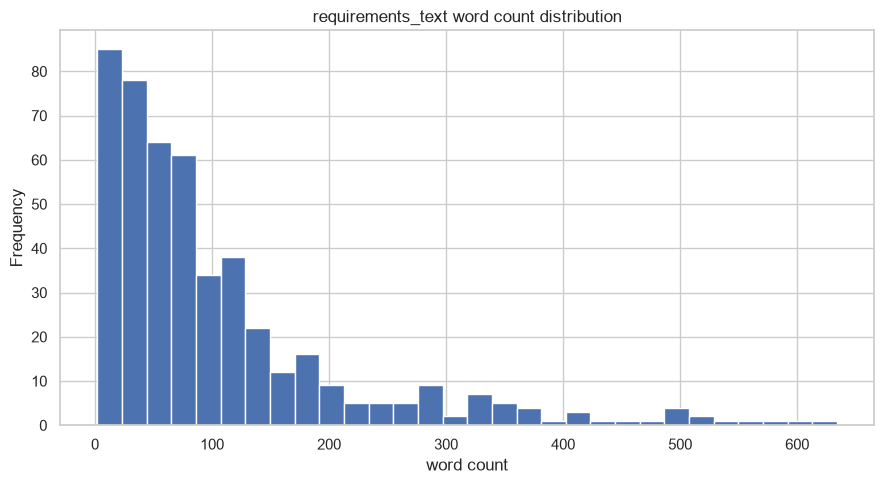

In [227]:
word_counts = text_col.fillna("").str.split().str.len()
print(word_counts.describe())
 
word_counts.plot(kind="hist", bins=30, title="requirements_text word count distribution")
plt.xlabel("word count")
plt.tight_layout()
plt.show()

In [228]:
df.columns

Index(['id', 'source', 'source_url', 'application_url', 'organisation',
       'description', 'discipline', 'opportunity_type', 'country', 'city',
       'funding', 'application_fee', 'career_stage', 'description_en',
       'discipline_en', 'opportunity_type_en', 'career_stage_en', 'country_en',
       'city_en', 'discipline_canonical', 'opportunity_type_canonical',
       'career_stage_canonical', 'country_canonical', 'funding_components',
       'funding_extracted_at', 'application_fee_has_fee',
       'application_fee_amount_min', 'application_fee_amount_max',
       'application_fee_currency', 'language', 'title', 'requirements_text',
       'title_en', 'requirements_text_en', 'deadline_raw', 'deadline_date',
       'processed_at'],
      dtype='str')

                                       n  pct_funded  pct_fee  avg_word_count
source                                                                       
acc_galerie_weimar                     2        1.00     0.00           59.00
akademie_schloss_solitude              1        1.00     0.00          307.00
arts_council_wales                    11        1.00     0.00          116.36
bmwkms_austria                         5        1.00     0.00          146.20
bozar_brussels                         1        0.00     0.00           29.00
can_serrat                             4        1.00     0.00           37.75
cite_internationale_des_arts           9        0.89     0.00           95.56
creative_ireland                       9        1.00     0.00          135.78
culture_gouv_fr_1pct                   3        0.67     0.00          112.00
cyprus_funding_programmes_culture      2        1.00     0.00          135.50
dansateliers_rotterdam                 2        0.50     0.00   

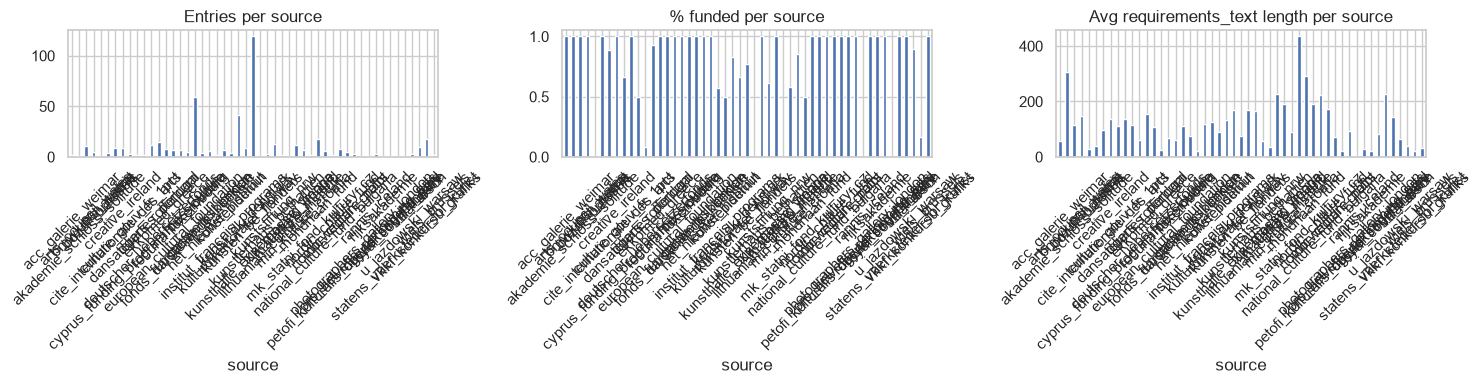

In [229]:
source_summary = df.groupby("source").agg(
    n=("id", "count"),
    pct_funded=("funding", lambda s: (s.notna() & (s.astype(str).str.strip() != "")).mean()),
    pct_fee=("application_fee", lambda s: (s.notna() & (s.astype(str).str.strip() != "")).mean()),
    avg_word_count=("requirements_text_en" if "requirements_text_en" in df.columns else "requirements_text",
                     lambda s: s.fillna("").str.split().str.len().mean()),
)
print(source_summary.round(2))
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
source_summary["n"].plot(kind="bar", ax=axes[0], title="Entries per source", rot=45)
source_summary["pct_funded"].plot(kind="bar", ax=axes[1], title="% funded per source", rot=45)
source_summary["avg_word_count"].plot(kind="bar", ax=axes[2], title="Avg requirements_text length per source", rot=45)
plt.tight_layout()
plt.show()

application_fee_currency      0.969
application_fee_amount_min    0.969
application_fee_amount_max    0.969
application_fee               0.927
application_fee_has_fee       0.927
career_stage_en               0.756
career_stage                  0.756
city_en                       0.566
city                          0.566
application_url               0.342
deadline_date                 0.251
funding_extracted_at          0.188
funding                       0.188
deadline_raw                  0.127
country                       0.088
country_en                    0.088
discipline                    0.010
discipline_en                 0.010
source_url                    0.000
source                        0.000
id                            0.000
organisation                  0.000
discipline_canonical          0.000
opportunity_type_canonical    0.000
opportunity_type_en           0.000
opportunity_type              0.000
description                   0.000
description_en              

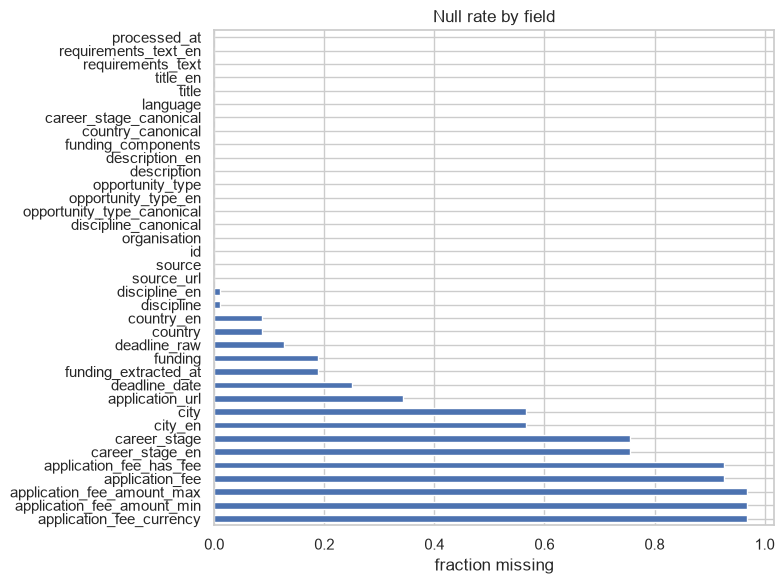

In [230]:
null_rate = df.isna().mean().sort_values(ascending=False)
print(null_rate.round(3))
 
null_rate.plot(kind="barh", title="Null rate by field", figsize=(8, 6))
plt.xlabel("fraction missing")
plt.tight_layout()
plt.show()

discipline           (other)  Visuelle Kunst  artists  literatúra  \
country                                                             
(other)                  248              11        3           1   
Belgium                   45               0        2           0   
France                    21               0        1           0   
Norge                     29               0        0           0   
Portugal                  17               0        0           0   
Slovensko                 25               0        0           7   
Slovenská republika       19               0        0           1   
Spain                     16               0        0           0   

discipline           performing arts  scenekunst  visual arts  Übersetzung  
country                                                                     
(other)                            4           2           12            6  
Belgium                            2           0            2            0  
F

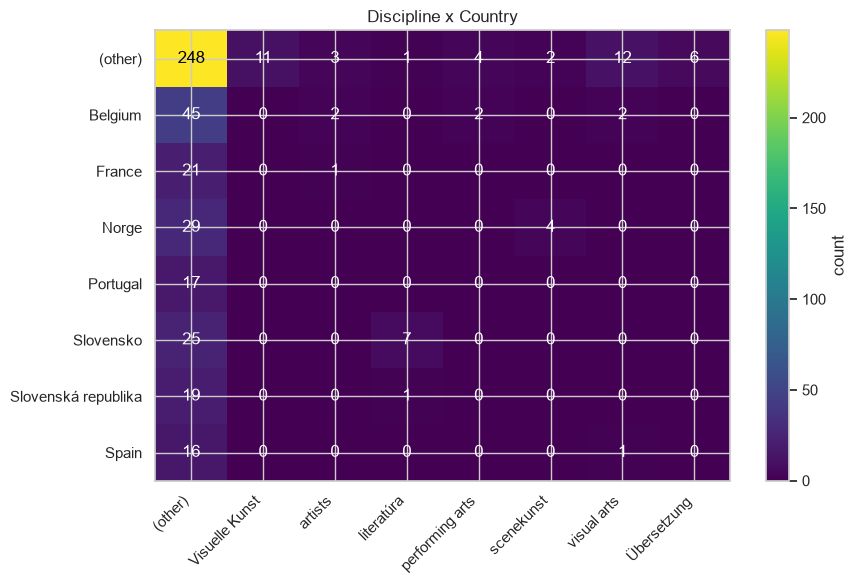

In [231]:
top_disciplines = df["discipline"].fillna("(not stated)").value_counts().head(8).index
top_countries = df["country"].fillna("(not stated)").value_counts().head(8).index
 
cross = pd.crosstab(
    df["country"].fillna("(not stated)").where(df["country"].isin(top_countries), "(other)"),
    df["discipline"].fillna("(not stated)").where(df["discipline"].isin(top_disciplines), "(other)"),
)
print(cross)
 
plt.figure(figsize=(9, 6))
plt.imshow(cross.values, aspect="auto", cmap="viridis")
plt.xticks(range(len(cross.columns)), cross.columns, rotation=45, ha="right")
plt.yticks(range(len(cross.index)), cross.index)
plt.colorbar(label="count")
plt.title("Discipline x Country")
for i in range(cross.shape[0]):
    for j in range(cross.shape[1]):
        plt.text(j, i, cross.values[i, j], ha="center", va="center",
                  color="white" if cross.values[i, j] < cross.values.max() / 2 else "black")
plt.tight_layout()
plt.show()


opportunity_type
Dotácia                                     50
grant                                       26
residency                                   25
Residency                                   23
open call                                   22
                                            ..
Reisestipendium                              1
open call for projects and collaborators     1
research projects                            1
residencia de producción artística           1
open script submissions                      1
Name: count, Length: 160, dtype: int64


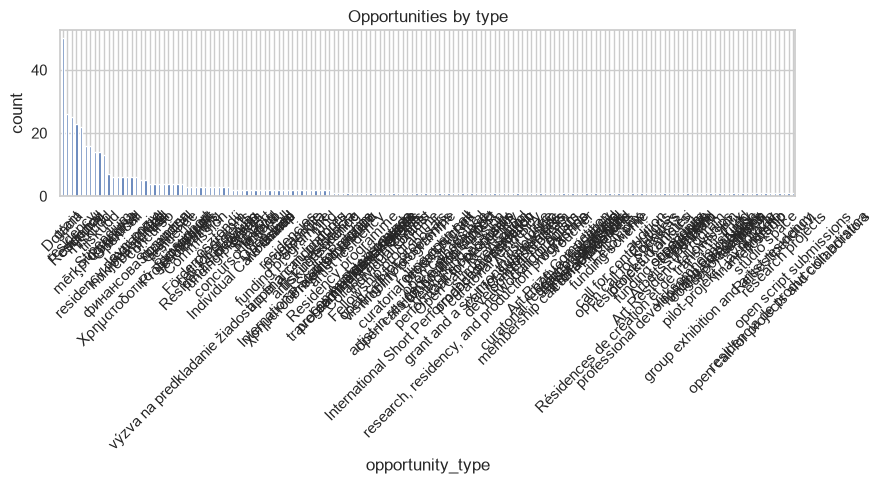

In [232]:
if "opportunity_type" in df.columns:
    type_counts = df["opportunity_type"].fillna("(not stated)").value_counts()
    print(type_counts)
 
    type_counts.plot(kind="bar", title="Opportunities by type", rot=45)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()
else:
    print("No `opportunity_type` column found.")

In [233]:
df.head(20)

,id,source,source_url,application_url,organisation,description,discipline,opportunity_type,country,city,funding,application_fee,career_stage,description_en,discipline_en,opportunity_type_en,career_stage_en,country_en,city_en,discipline_canonical,opportunity_type_canonical,career_stage_canonical,country_canonical,funding_components,funding_extracted_at,application_fee_has_fee,application_fee_amount_min,application_fee_amount_max,application_fee_currency,language,title,requirements_text,title_en,requirements_text_en,deadline_raw,deadline_date,processed_at
0,akademie_schloss_solitude_a8aba5b303e4,akademie_schloss_solitude,https://www.akademie-solitude.de/en/fellowship/solitude-fellowship/,https://application.akademie-solitude.de/fellowship-information/solitude-fel...,Akademie Schloss Solitude,The Akademie Schloss Solitude in Stuttgart awards between 50 and 60 residenc...,all disciplines,residency,Germany,Stuttgart,"A monthly fellowship of €1,300 to cover living expenses",NaN,"artists, scholars, and cultural practitioners from around the world who have...",The Akademie Schloss Solitude in Stuttgart awards between 50 and 60 residenc...,all disciplines,residency,"artists, scholars, and cultural practitioners from around the world who have...",Germany,Stuttgart,['Multidisciplinary'],['Residency'],"['Established/Professional', 'Mid-Career']",['Germany'],"[{'category': 'Grant/Stipend', 'amount_min': 1300.0, 'amount_max': 1300.0, '...",2026-09-24 08:56:51.874575+00:00,NaN,NaN,NaN,NaN,en,Solitude Fellowship,"The fellowship is aimed at artists, scholars, and cultural practitioners fro...",Solitude Fellowship,"The fellowship is aimed at artists, scholars, and cultural practitioners fro...",NaN,NaN,2026-09-23 12:36:39.258102+00:00
1,bmwkms_austria_57c6352e8fbc,bmwkms_austria,https://www.bmwkms.gv.at/themen/kunst-und-kultur/service-kunst-und-kultur/ku...,https://www.bmkoes.gv.at/kunst-und-kultur/service-kunst-und-kultur/foerderun...,"Bundesministerium für Wohnen, Kunst, Kultur, Medien und Sport",Die Kunst- und Kulturszene lebt vom ständigen Austausch auf internationaler ...,"bildende Kunst, Fotografie und Medienkunst",Stipendium,Österreich,NaN,"Mit der Vergabe der Ateliers, die einzelnen Künstler:innen abhängig vom Atel...",NaN,NaN,The art and cultural scene thrives on constant exchange at the international...,"visual arts, photography and media art",stipend,NaN,Austria,NaN,"['Visual Arts', 'Photography', 'Digital/New Media Arts']",['Grant/Funding'],[],['Austria'],"[{'category': 'Grant/Stipend', 'amount_min': 2000.0, 'amount_max': 2000.0, '...",2026-09-24 08:56:51.874736+00:00,NaN,NaN,NaN,NaN,de,Ausschreibung Auslandsstipendien für Künstler:innen der Bereiche bildende Ku...,"Antragsberechtigt sind Künstler:innen , die die österreichische Staatsbürger...",Call for applications: foreign residencies for artists in the fields of visu...,Artists who hold Austrian citizenship or have their permanent residence in A...,30. September 2026,2026-09-30,2026-09-23 12:36:41.344018+00:00
2,bmwkms_austria_36f95e7e131b,bmwkms_austria,https://www.bmwkms.gv.at/themen/kunst-und-kultur/service-kunst-und-kultur/ku...,https://transparenzportal.gv.at/tdb/tp/menu_ml_meineLeistungen,"BMWKMS (Bundesministerium für Kunst, Kultur, öffentlichen Dienst und Sport)",Die Staatsstipendien stellen eine Anerkennung bisheriger hervorragender küns...,"Bildende Kunst, Fotografie und Medienkunst",Stipendium,Österreich,NaN,"Dotierung mit je EUR 18.000,00",NaN,NaN,The state grants constitute recognition of previous outstanding artistic ach...,"visual arts, photography and media art",stipend,NaN,Austria,NaN,"['Visual Arts', 'Photography', 'Digital/New Media Arts']",['Grant/Funding'],[],['Austria'],"[{'category': 'Grant/Stipend', 'amount_min': 18000.0, 'amount_max': 18000.0,...",2026-09-24 08:56:51.874778+00:00,NaN,NaN,NaN,NaN,de,"Staatsstipendien 2027: Bildende Kunst, Fotografie und Medienkunst","Eingeladen sind Künstler:innen (ausschließlich Einzelpersonen), die die öste...","State S